In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("crawford/emnist")

print("Path to dataset files:", path)

c:\Users\alibu\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.24G/1.24G [08:52<00:00, 2.50MB/s] 

Extracting files...


Path to dataset files: C:\Users\alibu\.cache\kagglehub\datasets\crawford\emnist\versions\3


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd

variant = "balanced"
data_dir = Path(path)
train_file = data_dir / f"emnist-{variant}-train.csv"
test_file = data_dir / f"emnist-{variant}-test.csv"

if not train_file.exists() or not test_file.exists():
    raise FileNotFoundError(f"Could not find EMNIST files for variant: {variant}")


def load_emnist_csv(file_path):
    data = pd.read_csv(file_path, header=None).to_numpy(dtype=np.uint8)
    labels = data[:, 0].astype(np.int64)
    images = data[:, 1:].reshape(-1, 28, 28).transpose(0, 2, 1)
    return images.astype(np.float32) / 255.0, labels


X_train, y_train = load_emnist_csv(train_file)
X_test, y_test = load_emnist_csv(test_file)

X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

output_file = Path.cwd() / f"emnist_{variant}_preprocessed.npz"
np.savez_compressed(
    output_file,
    X_train=X_train_flat,
    y_train=y_train,
    X_test=X_test_flat,
    y_test=y_test,
)

print(f"Saved: {output_file}")
print(f"Train features: {X_train_flat.shape}, labels: {y_train.shape}")
print(f"Test features:  {X_test_flat.shape}, labels: {y_test.shape}")
print(f"Pixel range: [{X_train_flat.min():.1f}, {X_train_flat.max():.1f}]")
print(f"Training classes: {np.unique(y_train).size}")

Saved: c:\Users\alibu\OneDrive\Desktop\Project\emnist_balanced_preprocessed.npz
Train features: (112800, 784), labels: (112800,)
Test features:  (18800, 784), labels: (18800,)
Pixel range: [0.0, 1.0]
Training classes: 47


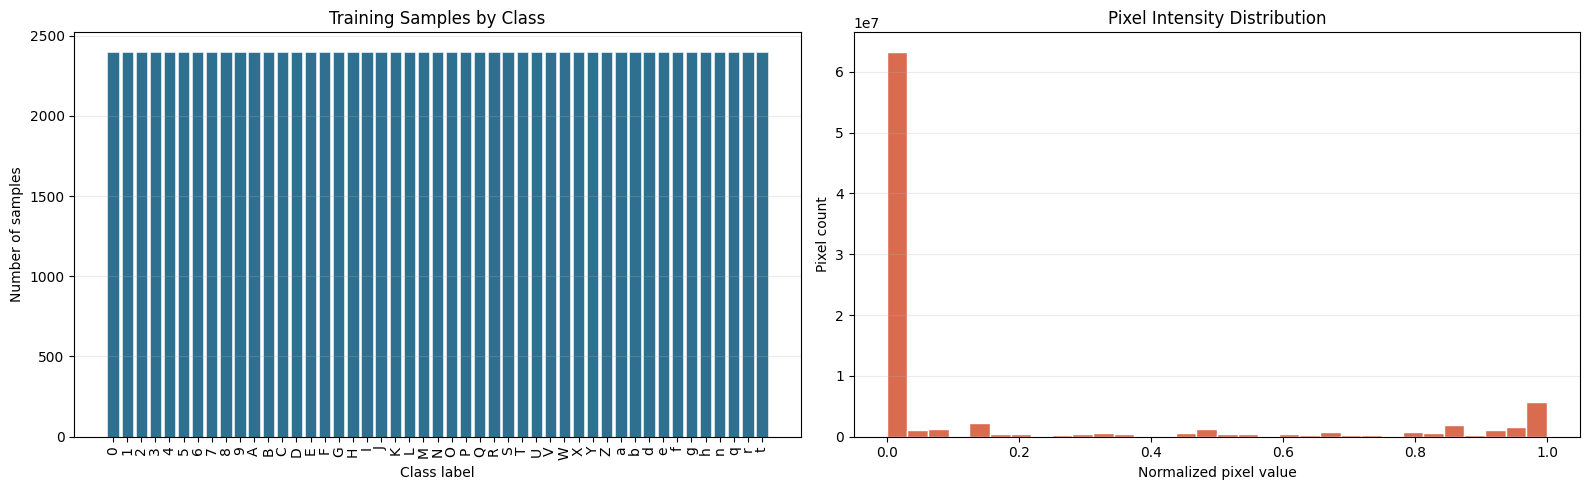

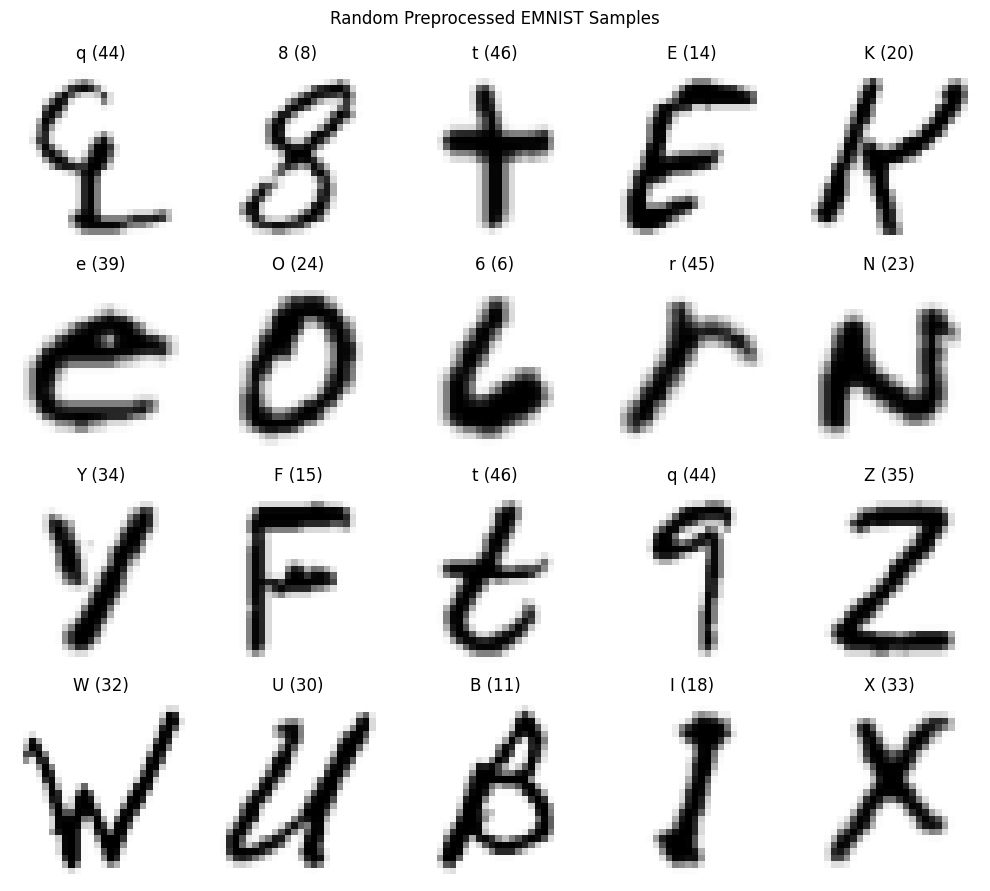

In [4]:
import matplotlib.pyplot as plt

mapping_file = data_dir / f"emnist-{variant}-mapping.txt"
label_mapping = {
    int(label): chr(int(codepoint))
    for label, codepoint in np.loadtxt(mapping_file, dtype=int)
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

class_counts = np.bincount(y_train, minlength=len(label_mapping))
axes[0].bar(
    range(len(class_counts)),
    class_counts,
    color="#2f6f8f",
    edgecolor="white",
    linewidth=0.4,
)
axes[0].set_title("Training Samples by Class")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].set_xticks(range(len(class_counts)))
axes[0].set_xticklabels([label_mapping[i] for i in range(len(class_counts))], rotation=90)
axes[0].grid(axis="y", alpha=0.25)

axes[1].hist(X_train_flat.ravel(), bins=32, color="#d96c4f", edgecolor="white")
axes[1].set_title("Pixel Intensity Distribution")
axes[1].set_xlabel("Normalized pixel value")
axes[1].set_ylabel("Pixel count")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

rng = np.random.default_rng(42)
sample_indices = rng.choice(len(X_train), size=20, replace=False)
fig, axes = plt.subplots(4, 5, figsize=(10, 9))
for axis, index in zip(axes.flat, sample_indices):
    axis.imshow(X_train[index], cmap="gray_r", vmin=0, vmax=1)
    axis.set_title(f"{label_mapping[y_train[index]]} ({y_train[index]})")
    axis.axis("off")

fig.suptitle("Random Preprocessed EMNIST Samples", y=0.99)
plt.tight_layout()
plt.show()

Epoch 1/10 - loss: 3.4782 - test accuracy: 0.156
Epoch 2/10 - loss: 2.6103 - test accuracy: 0.471
Epoch 3/10 - loss: 2.0288 - test accuracy: 0.604
Epoch 4/10 - loss: 1.6255 - test accuracy: 0.608
Epoch 5/10 - loss: 1.3756 - test accuracy: 0.709
Epoch 6/10 - loss: 1.1976 - test accuracy: 0.729
Epoch 7/10 - loss: 1.0708 - test accuracy: 0.740
Epoch 8/10 - loss: 0.9871 - test accuracy: 0.717
Epoch 9/10 - loss: 0.9239 - test accuracy: 0.772
Epoch 10/10 - loss: 0.8697 - test accuracy: 0.777
Device: cpu
Saved: c:\Users\alibu\OneDrive\Desktop\Project\emnist_cnn.pt
CRNN-ready feature sequence shape: (1, 7, 896)


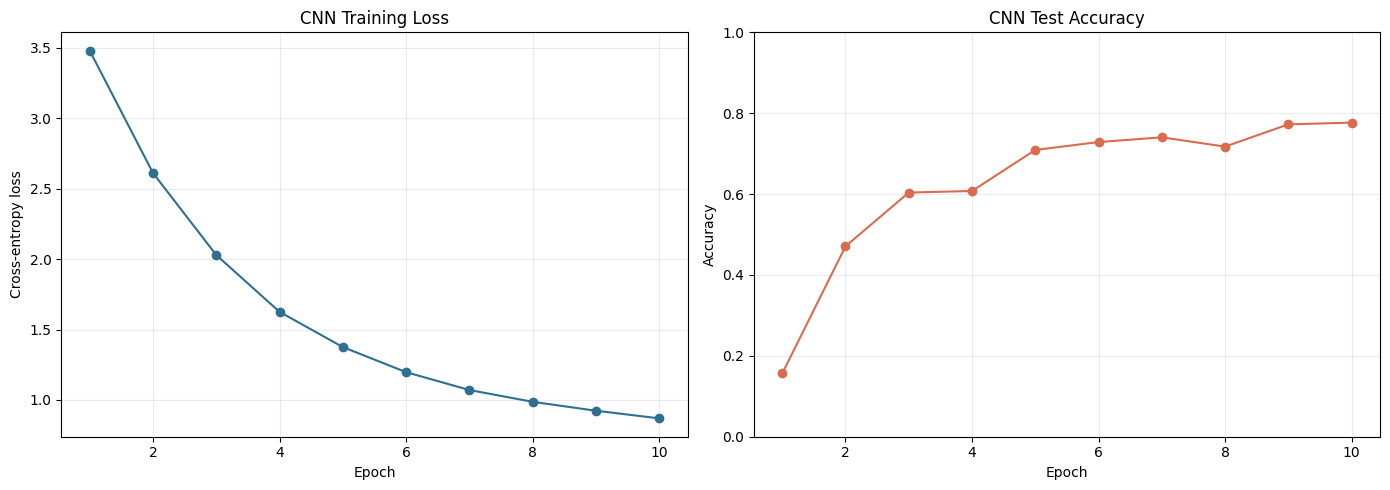

In [11]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

artifact = np.load(Path.cwd() / "emnist_balanced_preprocessed.npz")
train_limit = min(20000, len(artifact["X_train"]))
test_limit = min(5000, len(artifact["X_test"]))
epochs = 10

X_train_cnn = artifact["X_train"][:train_limit].reshape(-1, 1, 28, 28).astype("float32")
y_train_cnn = artifact["y_train"][:train_limit].astype("int64")
X_test_cnn = artifact["X_test"][:test_limit].reshape(-1, 1, 28, 28).astype("float32")
y_test_cnn = artifact["y_test"][:test_limit].astype("int64")

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train_cnn), torch.from_numpy(y_train_cnn)),
    batch_size=256,
    shuffle=True,
)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test_cnn), torch.from_numpy(y_test_cnn)),
    batch_size=512,
)


class EMNISTCNN(nn.Module):
    def __init__(self, number_of_classes):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(128, number_of_classes),
        )

    def forward(self, images):
        return self.classifier(self.feature_extractor(images))

    def sequence_features(self, images):
        feature_map = self.feature_extractor(images)
        return feature_map.permute(0, 2, 1, 3).flatten(2)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = EMNISTCNN(number_of_classes=int(y_train_cnn.max() + 1)).to(device)
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

training_losses = []
test_accuracies = []
for epoch in range(epochs):
    cnn_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = loss_function(cnn_model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(images)
    training_losses.append(running_loss / train_limit)

    cnn_model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            correct += (cnn_model(images).argmax(1) == labels).sum().item()
    test_accuracies.append(correct / test_limit)
    print(f"Epoch {epoch + 1}/{epochs} - loss: {training_losses[-1]:.4f} - test accuracy: {test_accuracies[-1]:.3f}")

cnn_model.eval()
with torch.no_grad():
    feature_sequence_shape = cnn_model.sequence_features(torch.from_numpy(X_test_cnn[:1]).to(device)).shape

torch.save(cnn_model.state_dict(), Path.cwd() / "emnist_cnn.pt")
print(f"Device: {device}")
print(f"Saved: {Path.cwd() / 'emnist_cnn.pt'}")
print(f"CRNN-ready feature sequence shape: {tuple(feature_sequence_shape)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epoch_numbers = range(1, epochs + 1)
axes[0].plot(epoch_numbers, training_losses, marker="o", color="#2f6f8f")
axes[0].set_title("CNN Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].grid(alpha=0.25)

axes[1].plot(epoch_numbers, test_accuracies, marker="o", color="#d96c4f")
axes[1].set_title("CNN Test Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

Loaded trained model: c:\Users\alibu\OneDrive\Desktop\Project\emnist_cnn.pt
Input character: 8
Predicted character: 8
Confidence: 69.39%


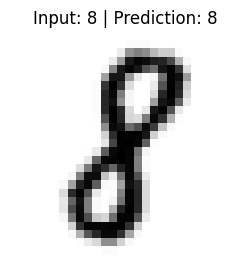

In [12]:
# Load the trained CNN, then classify one character from the EMNIST test set.
from pathlib import Path
import kagglehub

mapping_file = Path(kagglehub.dataset_download("crawford/emnist")) / "emnist-balanced-mapping.txt"
label_mapping = {
    int(label): chr(int(codepoint))
    for label, codepoint in np.loadtxt(mapping_file, dtype=int)
}

model_path = Path.cwd() / "emnist_cnn.pt"
if not model_path.exists():
    raise FileNotFoundError("Train the CNN first so emnist_cnn.pt is available.")

loaded_model = EMNISTCNN(number_of_classes=len(label_mapping)).to(device)
loaded_model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
loaded_model.eval()
print(f"Loaded trained model: {model_path}")

character_input = input("Enter one character (0-9 or A-Z): ").strip()
if len(character_input) != 1:
    raise ValueError("Please enter exactly one character.")

matching_labels = [label for label, character in label_mapping.items() if character.lower() == character_input.lower()]
if not matching_labels:
    raise ValueError(f"Character {character_input!r} is not available in the EMNIST Balanced labels.")

requested_label = matching_labels[0]
matching_indices = np.flatnonzero(y_test_cnn == requested_label)
if len(matching_indices) == 0:
    raise ValueError("No test image is available for that character in the selected test sample.")

sample_index = int(matching_indices[0])
input_image = torch.from_numpy(X_test_cnn[sample_index:sample_index + 1]).to(device)
with torch.no_grad():
    probabilities = torch.softmax(loaded_model(input_image), dim=1)[0]
    predicted_label = int(probabilities.argmax().item())
    confidence = float(probabilities[predicted_label].item())

print(f"Input character: {character_input}")
print(f"Predicted character: {label_mapping[predicted_label]}")
print(f"Confidence: {confidence:.2%}")

plt.figure(figsize=(3, 3))
plt.imshow(X_test_cnn[sample_index, 0], cmap="gray_r", vmin=0, vmax=1)
plt.title(f"Input: {character_input} | Prediction: {label_mapping[predicted_label]}")
plt.axis("off")
plt.show()